In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")




In [8]:
df = pd.read_csv("ecommerce_customer_data_large.csv")
df.head()


,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,44605,2023-05-03 21:30:02,Home,177,1,2427,PayPal,31,1.0,John Rivera,31,Female,0
1,44605,2021-05-16 13:57:44,Electronics,174,3,2448,PayPal,31,1.0,John Rivera,31,Female,0
2,44605,2020-07-13 06:16:57,Books,413,1,2345,Credit Card,31,1.0,John Rivera,31,Female,0
3,44605,2023-01-17 13:14:36,Electronics,396,3,937,Cash,31,0.0,John Rivera,31,Female,0
4,44605,2021-05-01 11:29:27,Books,259,4,2598,PayPal,31,1.0,John Rivera,31,Female,0


In [10]:
df.shape


(250000, 13)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  object 
 2   Product Category       250000 non-null  object 
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  object 
 7   Customer Age           250000 non-null  int64  
 8   Returns                202618 non-null  float64
 9   Customer Name          250000 non-null  object 
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  object 
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 24.8+ MB


In [14]:
df.describe()

,Customer ID,Product Price,Quantity,Total Purchase Amount,Customer Age,Returns,Age,Churn
count,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,202618.000000,250000.000000,250000.00000
mean,25017.632092,254.742724,3.004936,2725.385196,43.798276,0.500824,43.798276,0.20052
std,14412.515718,141.738104,1.414737,1442.576095,15.364915,0.500001,15.364915,0.40039
min,1.000000,10.000000,1.000000,100.000000,18.000000,0.000000,18.000000,0.00000
25%,12590.000000,132.000000,2.000000,1476.000000,30.000000,0.000000,30.000000,0.00000
50%,25011.000000,255.000000,3.000000,2725.000000,44.000000,1.000000,44.000000,0.00000
75%,37441.250000,377.000000,4.000000,3975.000000,57.000000,1.000000,57.000000,0.00000
max,50000.000000,500.000000,5.000000,5350.000000,70.000000,1.000000,70.000000,1.00000


In [24]:
df.isnull().sum()

Customer ID              0
Purchase Date            0
Product Category         0
Product Price            0
Quantity                 0
Total Purchase Amount    0
Payment Method           0
Customer Age             0
Returns                  0
Customer Name            0
Age                      0
Gender                   0
Churn                    0
dtype: int64

In [27]:
df.dropna(inplace=True)

In [29]:
df.duplicated().sum()

np.int64(0)

In [31]:
df.drop_duplicates(inplace=True)

In [33]:
df["Purchase Date"] = pd.to_datetime(df["Purchase Date"])

In [35]:
df["Year"] = df["Purchase Date"].dt.year
df["Month"] = df["Purchase Date"].dt.month_name()
df["Day"] = df["Purchase Date"].dt.day

In [37]:
plt.savefig("gender_distribution.png")

<Figure size 640x480 with 0 Axes>

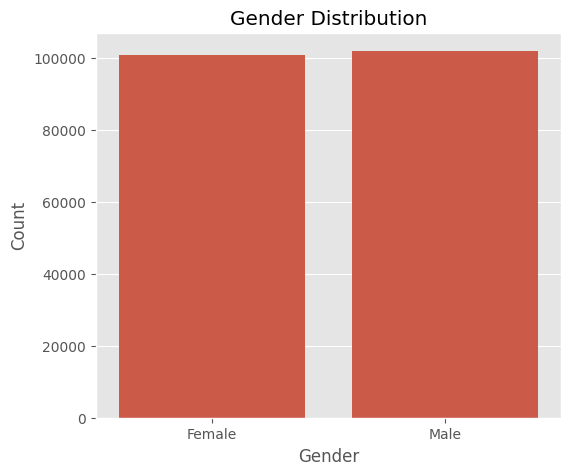

In [42]:
plt.figure(figsize=(6,5))
sns.countplot(x='Gender', data=df)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.savefig("gender_distribution.png")
plt.show()

### Observation

- The chart shows the distribution of customers by gender.
- Male and female customer counts can be compared easily.
- This helps understand the customer demographics.

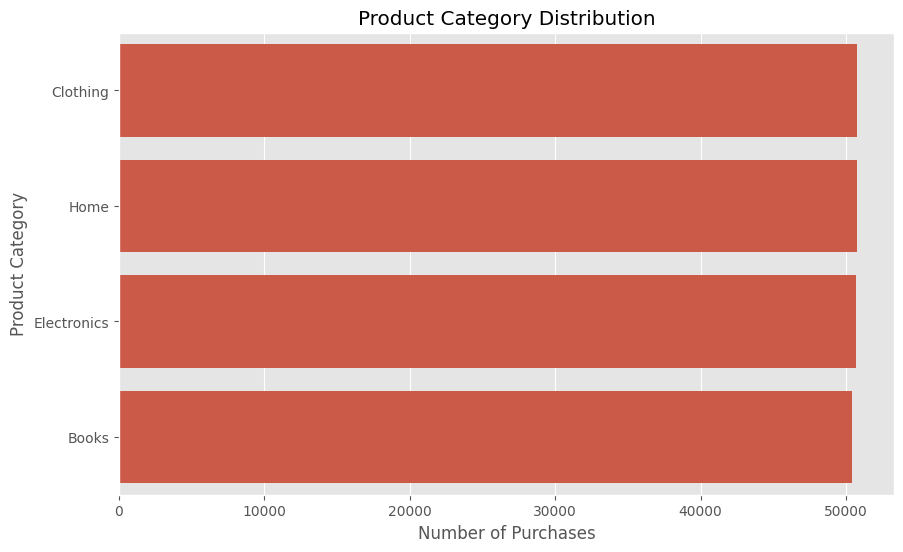

In [46]:
plt.figure(figsize=(10,6))

sns.countplot(
    y='Product Category',
    data=df,
    order=df['Product Category'].value_counts().index
)

plt.title("Product Category Distribution")
plt.xlabel("Number of Purchases")
plt.ylabel("Product Category")

plt.savefig("product_category_distribution.png")
plt.show()

### Observation

- This chart shows the number of purchases made in each product category.
- Categories with higher purchase counts indicate products that are more popular among customers.
- The results can help businesses focus on high-demand product categories.

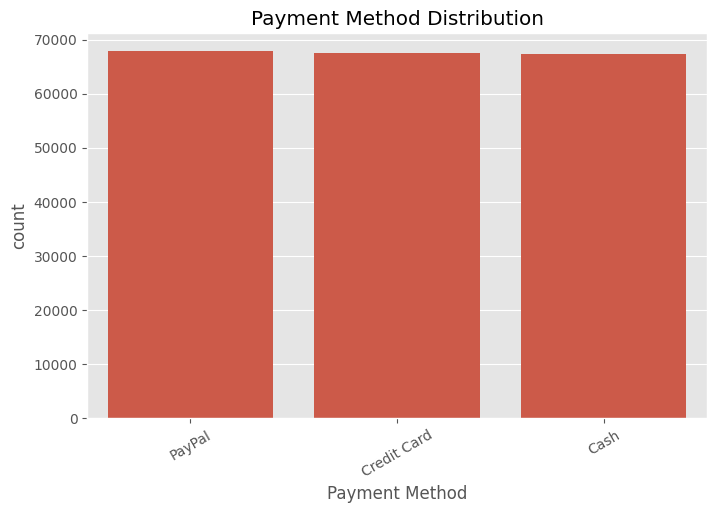

In [47]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Payment Method',
    data=df
)

plt.title("Payment Method Distribution")
plt.xticks(rotation=30)

plt.savefig("payment_method_distribution.png")
plt.show()

### Observation

- The chart illustrates the payment methods preferred by customers.
- It helps identify the most commonly used payment option for transactions.
- Businesses can use this information to improve payment services and customer convenience.

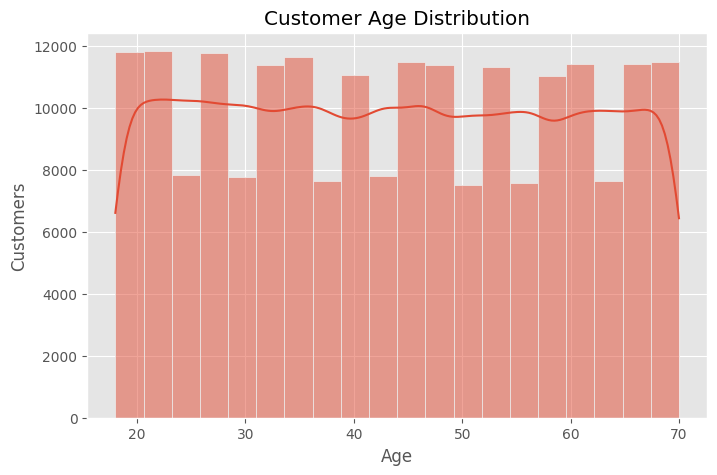

In [48]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Customer Age'],
    bins=20,
    kde=True
)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Customers")

plt.savefig("age_distribution.png")
plt.show()

### Observation

- The histogram represents the distribution of customer ages.
- It helps identify the major age groups contributing to sales.
- This information can be useful for developing age-specific marketing campaigns.

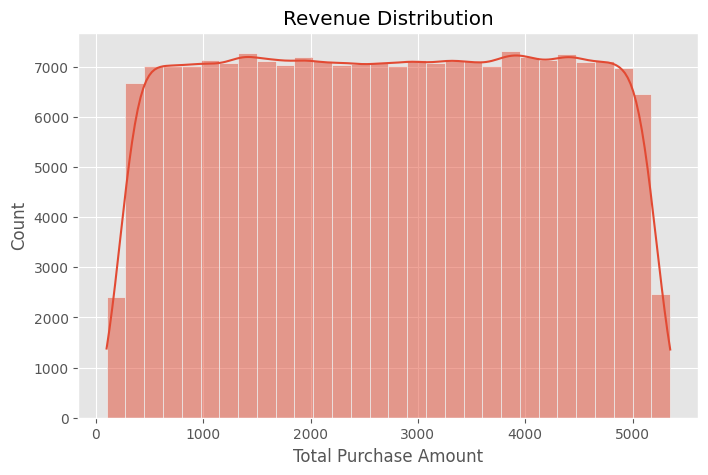

In [50]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Total Purchase Amount'],
    bins=30,
    kde=True
)

plt.title("Revenue Distribution")

plt.savefig("revenue_distribution.png")
plt.show()

### Observation

- This chart displays the distribution of total purchase amounts across all transactions.
- It helps identify common spending patterns and the presence of high-value purchases.
- The distribution provides insights into customer purchasing behavior.

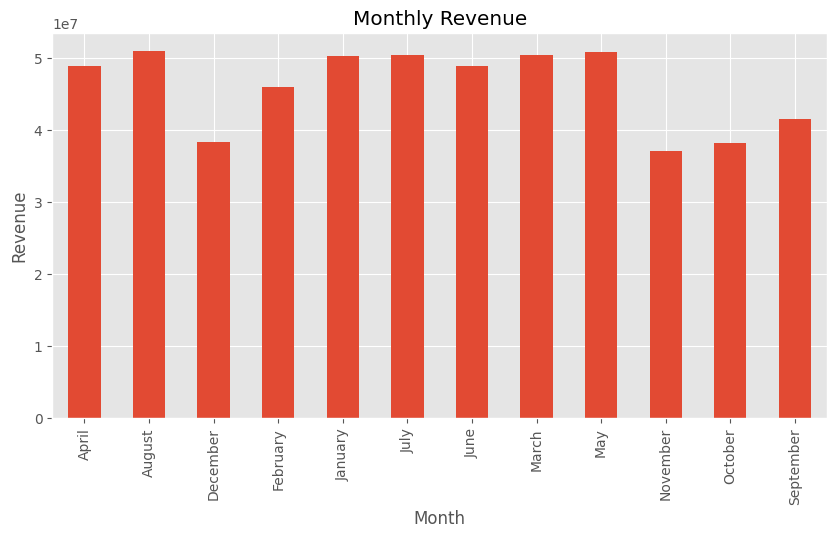

In [52]:
monthly_sales = df.groupby('Month')['Total Purchase Amount'].sum()

plt.figure(figsize=(10,5))

monthly_sales.plot(kind='bar')

plt.title("Monthly Revenue")
plt.ylabel("Revenue")

plt.savefig("monthly_revenue.png")
plt.show()

### Observation

- The chart shows the total revenue generated in each month.
- It helps identify months with higher or lower sales performance.
- Seasonal sales trends can be observed and used for future business planning.

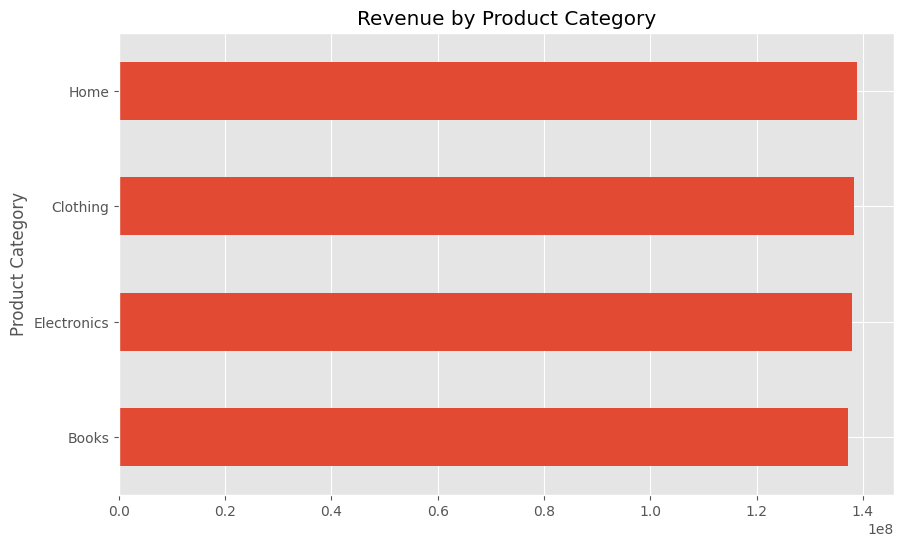

In [53]:
category_sales = df.groupby('Product Category')['Total Purchase Amount'].sum()

plt.figure(figsize=(10,6))

category_sales.sort_values().plot(kind='barh')

plt.title("Revenue by Product Category")

plt.savefig("category_revenue.png")
plt.show()

### Observation

- This chart compares the revenue generated by different product categories.
- Product categories with higher revenue contribute more significantly to overall business performance.
- Businesses can prioritize these categories for promotions and inventory management.

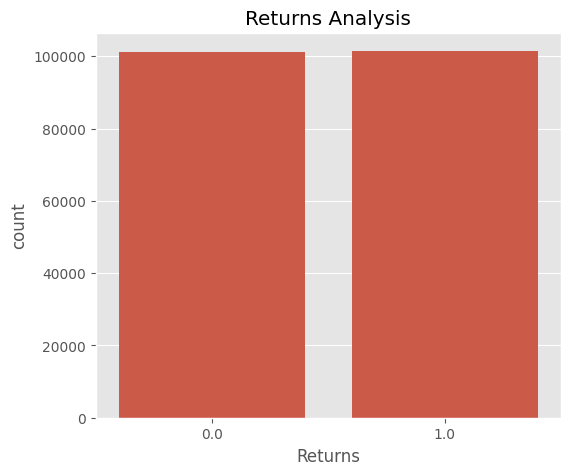

In [54]:
plt.figure(figsize=(6,5))

sns.countplot(
    x='Returns',
    data=df
)

plt.title("Returns Analysis")

plt.savefig("returns_analysis.png")
plt.show()

### Observation

- The chart compares the number of returned and non-returned products.
- It helps evaluate the overall return rate of customer purchases.
- A high number of returns may indicate issues related to product quality or customer satisfaction.

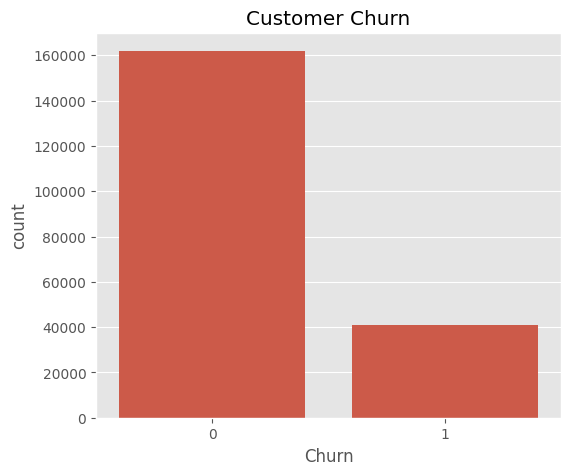

In [55]:
plt.figure(figsize=(6,5))

sns.countplot(
    x='Churn',
    data=df
)

plt.title("Customer Churn")

plt.savefig("customer_churn.png")
plt.show()

### Observation

- This chart displays the number of active and churned customers.
- It helps measure customer retention and identify potential customer loss.
- Understanding churn patterns can support the development of effective customer retention strategies.

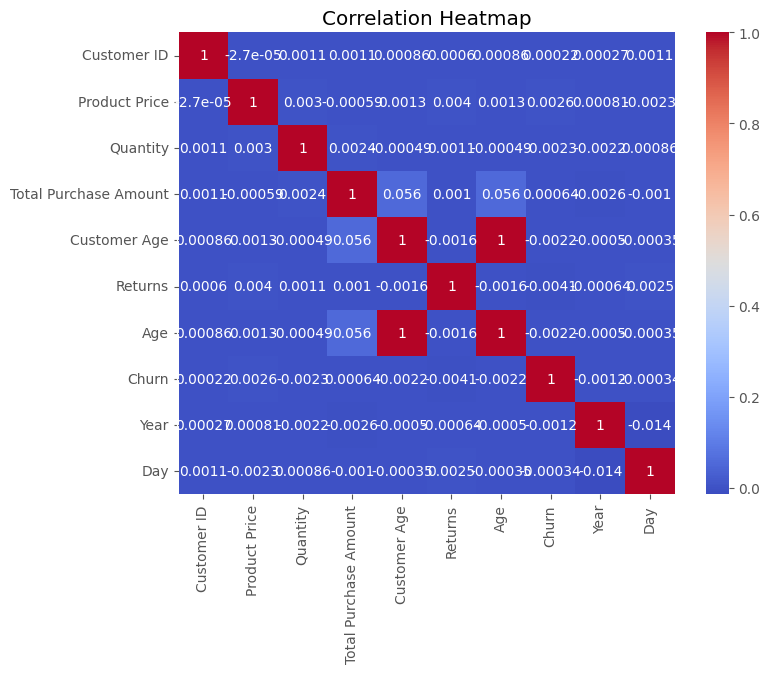

In [56]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.savefig("correlation_heatmap.png")
plt.show()

### Observation

- The heatmap illustrates the correlation between numerical variables in the dataset.
- Positive values indicate a direct relationship, while negative values indicate an inverse relationship.
- Strong correlations can help identify important factors influencing customer purchasing behavior.

## Part 1 Summary

The dataset was successfully loaded and explored using Python and Pandas. Data cleaning involved checking for missing values, duplicate records, and verifying data types. Exploratory Data Analysis (EDA) was performed using various visualizations to understand customer demographics, purchasing patterns, payment preferences, revenue distribution, product performance, returns, and customer churn. These analyses provide valuable insights into customer behavior and establish a strong foundation for advanced customer segmentation and business recommendations in the next phase of the project.

In [60]:
df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])

In [61]:
df['Year'] = df['Purchase Date'].dt.year
df['Month'] = df['Purchase Date'].dt.month_name()
df['Day'] = df['Purchase Date'].dt.day

In [63]:
purchase_frequency = df.groupby('Customer ID').size().reset_index(name='Purchase Frequency')

purchase_frequency.head()

,Customer ID,Purchase Frequency
0,1,1
1,2,6
2,3,1
3,4,5
4,5,3


In [65]:
customer_spending = df.groupby('Customer ID')['Total Purchase Amount'].sum().reset_index()

customer_spending.rename(columns={
    'Total Purchase Amount':'Total Spending'
}, inplace=True)

customer_spending.head()

,Customer ID,Total Spending
0,1,5148
1,2,16481
2,3,4687
3,4,7826
4,5,7681


In [67]:
average_purchase = df.groupby('Customer ID')['Total Purchase Amount'].mean().reset_index()

average_purchase.rename(columns={
    'Total Purchase Amount':'Average Purchase'
}, inplace=True)

In [69]:
customer_data = purchase_frequency.merge(customer_spending,on='Customer ID')

customer_data = customer_data.merge(
    average_purchase,
    on='Customer ID'
)

customer_data.head()

,Customer ID,Purchase Frequency,Total Spending,Average Purchase
0,1,1,5148,5148.000000
1,2,6,16481,2746.833333
2,3,1,4687,4687.000000
3,4,5,7826,1565.200000
4,5,3,7681,2560.333333


In [71]:
snapshot_date = df['Purchase Date'].max() + pd.Timedelta(days=1)

recency = df.groupby('Customer ID')['Purchase Date'].max().reset_index()

recency['Recency'] = (
    snapshot_date -
    recency['Purchase Date']
).dt.days

recency.head()

,Customer ID,Purchase Date,Recency
0,1,2021-04-08 18:33:34,889
1,2,2023-07-03 17:26:19,73
2,3,2023-02-03 03:58:07,223
3,4,2022-06-29 03:41:09,442
4,5,2022-03-25 08:43:48,538


In [73]:
frequency = df.groupby('Customer ID').size().reset_index(name='Frequency')

In [76]:
monetary = df.groupby('Customer ID')['Total Purchase Amount'].sum().reset_index()

monetary.rename(columns={
    'Total Purchase Amount':'Monetary'
}, inplace=True)

In [78]:
rfm = recency[['Customer ID','Recency']]

rfm = rfm.merge(frequency,on='Customer ID')

rfm = rfm.merge(monetary,on='Customer ID')

rfm.head()

,Customer ID,Recency,Frequency,Monetary
0,1,889,1,5148
1,2,73,6,16481
2,3,223,1,4687
3,4,442,5,7826
4,5,538,3,7681


In [80]:
rfm['R_Score'] = pd.qcut(
    rfm['Recency'],
    4,
    labels=[4,3,2,1]
)

rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    4,
    labels=[1,2,3,4]
)

rfm['M_Score'] = pd.qcut(
    rfm['Monetary'],
    4,
    labels=[1,2,3,4]
)

In [82]:
rfm['RFM Score'] = (
    rfm['R_Score'].astype(int)
    +
    rfm['F_Score'].astype(int)
    +
    rfm['M_Score'].astype(int)
)

rfm.head()

,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM Score
0,1,889,1,5148,1,1,1,3
1,2,73,6,16481,4,4,4,12
2,3,223,1,4687,3,1,1,5
3,4,442,5,7826,2,3,2,7
4,5,538,3,7681,1,1,2,4


In [84]:
def segment(score):

    if score >= 10:
        return "High Value"

    elif score >= 7:
        return "Loyal"

    elif score >= 5:
        return "Regular"

    else:
        return "At Risk"

rfm['Customer Segment'] = rfm['RFM Score'].apply(segment)

rfm.head()

,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM Score,Customer Segment
0,1,889,1,5148,1,1,1,3,At Risk
1,2,73,6,16481,4,4,4,12,High Value
2,3,223,1,4687,3,1,1,5,Regular
3,4,442,5,7826,2,3,2,7,Loyal
4,5,538,3,7681,1,1,2,4,At Risk


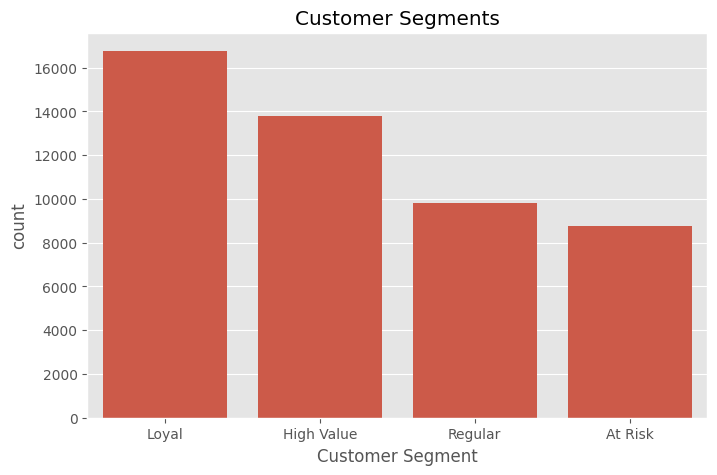

In [86]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Customer Segment',
    data=rfm,
    order=rfm['Customer Segment'].value_counts().index
)

plt.title("Customer Segments")

plt.show()

### Observation

- Customers are divided into four groups based on their RFM scores.
- High Value customers contribute significantly to business revenue.
- At Risk customers may require targeted retention strategies.

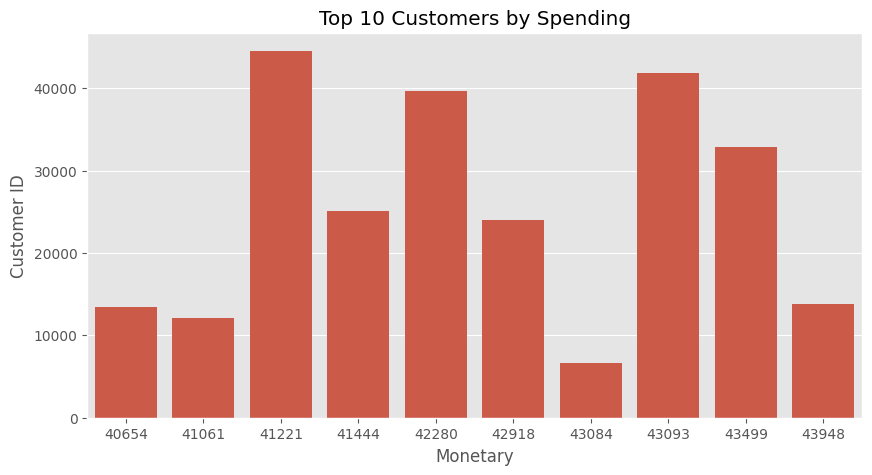

In [88]:
top10 = rfm.sort_values(
    by='Monetary',
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x='Monetary',
    y='Customer ID',
    data=top10
)

plt.title("Top 10 Customers by Spending")

plt.show()

### Observation

- The chart highlights the top 10 highest-spending customers.
- These customers contribute a significant share of total revenue.
- Rewarding these customers through loyalty programs can improve customer retention.

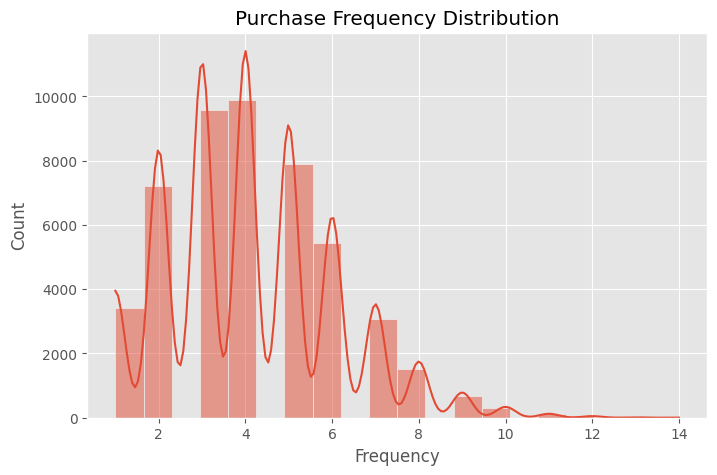

In [90]:
plt.figure(figsize=(8,5))

sns.histplot(
    rfm['Frequency'],
    bins=20,
    kde=True
)

plt.title("Purchase Frequency Distribution")

plt.show()

### Observation

- The chart displays how frequently customers make purchases.
- Most customers have a moderate purchase frequency, while a smaller group purchases very frequently.
- Businesses can encourage repeat purchases through personalized promotions and loyalty rewards.

## Business Recommendations

1. Reward high-value customers with exclusive discounts and loyalty benefits.

2. Launch personalized marketing campaigns to re-engage at-risk customers.

3. Promote best-selling product categories through targeted advertisements.

4. Encourage repeat purchases using membership programs and seasonal offers.

5. Improve customer satisfaction by analyzing return reasons and enhancing product quality.

## Part 2 Summary

Feature engineering was performed by calculating customer purchase frequency, total spending, and average purchase value. RFM (Recency, Frequency, Monetary) analysis was used to evaluate customer behavior and segment customers into High Value, Loyal, Regular, and At Risk groups. Additional visualizations highlighted customer segments, top spending customers, and purchase frequency patterns. These insights support strategic business decisions aimed at improving customer retention, increasing revenue, and enhancing overall customer satisfaction.

# Key Business Insights

## Insight 1
High-value customers contribute a significant portion of the total revenue. Retaining these customers should be a top priority through personalized offers and loyalty programs.

## Insight 2
Certain product categories generate higher sales than others. Increasing inventory and marketing efforts for these categories can improve overall revenue.

## Insight 3
Customer purchasing behavior varies across different months, indicating seasonal trends that businesses can leverage during promotions.

## Insight 4
The analysis of payment methods helps identify customers' preferred payment options, allowing businesses to optimize payment services.

## Insight 5
Customer churn analysis highlights customers who may stop purchasing. Early engagement strategies can improve customer retention.

# Business Recommendations

1. Introduce loyalty reward programs for high-value customers.

2. Launch personalized email and SMS marketing campaigns for customers who are at risk of churning.

3. Increase stock availability and promotional campaigns for the highest-selling product categories.

4. Improve customer experience by reducing product return rates through better quality control and customer support.

5. Analyze customer purchasing patterns regularly to develop targeted marketing strategies and maximize sales.

# Conclusion

This project successfully analyzed customer purchasing behavior using Python, Pandas, Matplotlib, and Seaborn. The dataset was cleaned and explored to understand customer demographics, purchasing trends, payment preferences, returns, and churn behavior.

RFM analysis was performed to segment customers into High Value, Loyal, Regular, and At Risk groups based on their purchasing behavior. The generated visualizations and business insights provide valuable information that can support data-driven decision-making.

The findings can help businesses improve customer retention, increase sales, optimize marketing strategies, and enhance customer satisfaction.

# Executive Summary

This project focuses on analyzing customer behavior using an e-commerce dataset containing 250,000 customer transactions.

The analysis began with data cleaning, including checking missing values, duplicate records, and correcting data types. Exploratory Data Analysis (EDA) was then performed to understand customer demographics, purchasing behavior, payment methods, revenue trends, product performance, returns, and customer churn.

Feature engineering was applied to calculate purchase frequency, total spending, and average purchase values. RFM (Recency, Frequency, Monetary) analysis was used to segment customers into meaningful groups.

The analysis identified high-value customers, purchasing trends, and customer retention opportunities. Business recommendations were provided to improve customer satisfaction, increase sales, and strengthen customer loyalty.